In [1]:
import torch
print(torch.device("cuda"))

cuda


In [2]:
import dataset as ds
dt = ds.Coco("/home/wanderer2414/coco2017/")

loading annotations into memory...
Done (t=7.82s)
creating index...
index created!
loading annotations into memory...
Done (t=0.07s)
creating index...
index created!


In [3]:
from dataset import TensorToImg, ImgWrite, ImgRead, ImgToTensor
from torch import from_numpy, Tensor, autograd, device
import MyRCNN
autograd.set_detect_anomaly(True)

model = MyRCNN.Model(device=device("cuda"))
model.train(dt, MyRCNN.MyLoss)
# x =  AvgPool2d(3, stride=3, padding=1)(x)
# x = ((x*255/32).round()*32).clamp(max=255)/255
# img = ds.TensorToImg(x)
# img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
# x = from_numpy(img).float().unsqueeze(0)/255
# N, M = x.shape[1:3]
# p = x.pow(2)
# sum = AvgPool2d(3, stride=1, padding=1)(x)*9
# sum2 = AvgPool2d(3, stride=1, padding=1)(p)*9
# x:Tensor = 9*p + sum2 - 2*x*sum
# x = 1 - x/x.max()
# x = (x*10).round()/10
# x[x<=0.9]=0
# x = x.unsqueeze(-1).expand(*x.shape,3).permute(0, -1, 1, 2)
# img = TensorToImg(x)
# ImgWrite("out.png", img)
# import matplotlib.pyplot as plt
# plt.imshow(img)
# plt.show()

[00:00:52] tensor([4.5874], device='cuda:0', grad_fn=<DivBackward0>) ███████████████████████████████ 50       /       50


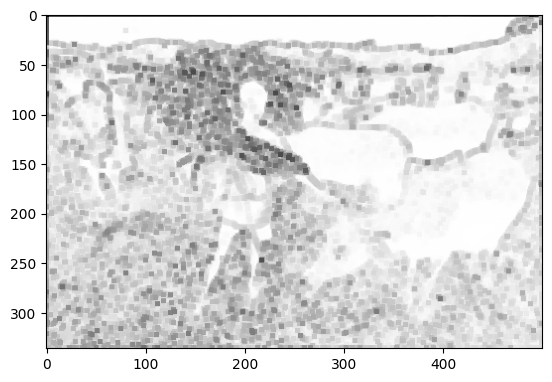

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
x = dt.getTrainTensor(2).to(device=device("cuda"))
# print(dt.getTrainLabel(0))
mask: Tensor = model.model.mask(x)
color = model.model.color(mask, x)

# B, C, W, H = x.shape
# x = x.permute(0, 2, 3, 1).view(x.shape[0], -1, 3)
# x = model.model.color.net1(x)
# x = x.view(B, C, W, H) - x.min()
# print(x)
x = mask
x = x.expand(1, 3, -1, -1)
# print(color)
# x = x.unsqueeze(0).expand(1, 3, -1, -1)
# print(x)
# ls: list[Tensor] = model.model(x.to(torch.device("cuda")))
# ls = [x.to(torch.device("cpu")) for x in ls]
img = ds.TensorToImg(x.to(device("cpu")).detach())
plt.imshow(img)

# side: float = 1
# for mat in ls:
#     mat = torch.softmax(mat, dim=-1)
#     side *= 5
#     M, I = mat.max(dim=-1)
#     indices = (M > 0.6) & (I>0)
#     H, W = mat.shape[1:3]
#     row = torch.arange(H, device=x.device).view(1, H, 1).expand(1, H, W)
#     col = torch.arange(W, device=x.device).view(1, 1, W).expand(1, H, W)
#     # print(mat.shape)
#     print(M.max())
#     print(I[indices])
#     position = torch.stack([row, col], dim=-1)[indices].to(device=device("cpu"))
#     for i in position:
#         rect = patches.Rectangle([i[1]*side,i[0]*side], side, side, edgecolor='red', facecolor='none')
#         plt.subplot().add_patch(rect)
# plt.show()
